# PRISM Rebuttal - corrected and redrawn figures

Two jobs.

**Redraws requested by Reviewer EiR7.** Figure 2 becomes a scatter plot rather
than a heatmap, and Figure 4 gets a perceptually uniform, colourblind-safe
scale checked in greyscale. Figure 5 is regenerated because the rendered
title still reads "Composite Reliability Index" while the caption says
Clinical Readiness Index.

**Figures that depend on numbers the corrections changed.** The OOD ECE
figure is redrawn over all six label fractions rather than the two endpoints,
which EiR7 asked for and which the data always supported. Two new figures
report the degeneracy audit and the rank-correlation contrast, both of which
answer Reviewer tp5b directly.

Reads `results_v2/`, writes to `figures_v2/`, leaving the original figures
untouched. CPU only.

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/PRISM'
RES    = f'{BASE}/results_v2'
FIGDIR = f'{BASE}/figures_v2'
os.makedirs(FIGDIR, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODELS = ['CLIP','PLIP','CONCH','VIRCHOW2','UNI','GigaPath','H-Optimus-0','MIDNIGHT']
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

# Okabe-Ito: colourblind-safe and distinguishable in greyscale by lightness
CB = ['#000000','#E69F00','#56B4E9','#009E73',
      '#F0E442','#0072B2','#D55E00','#CC79A7']
COLOR  = dict(zip(MODELS, CB))
MARKER = dict(zip(MODELS, ['o','s','^','D','v','P','X','*']))

# sequential, perceptually uniform, safe in greyscale
SEQ = 'cividis'
# diverging, colourblind-safe
DIV = LinearSegmentedColormap.from_list('cb_div',
        ['#0072B2', '#F7F7F7', '#D55E00'])

ind = pd.read_csv(f'{RES}/indomain_all_v2.csv')
ood = pd.read_csv(f'{RES}/ood_all_v2.csv')
deg = pd.read_csv(f'{RES}/degeneracy_audit.csv')
rc  = pd.read_csv(f'{RES}/rank_correlations.csv')
print('loaded:', len(ind), 'in-domain rows,', len(ood), 'OOD rows')
print('writing to', FIGDIR)

Mounted at /content/drive
loaded: 864 in-domain rows, 576 OOD rows
writing to /content/drive/MyDrive/PRISM/figures_v2


## Figure 2, redrawn as a scatter plot

EiR7: *"fig 2 is not color blind friendly and really hard to read. do scatter
plots instead"*.

Each point is one (model, dataset). The x axis is AUROC rank, the y axis is
calibration rank, both within the dataset. Points on the diagonal are models
whose two ranks agree; vertical distance from the diagonal is the
displacement. Two panels contrast 1% labels with full supervision.

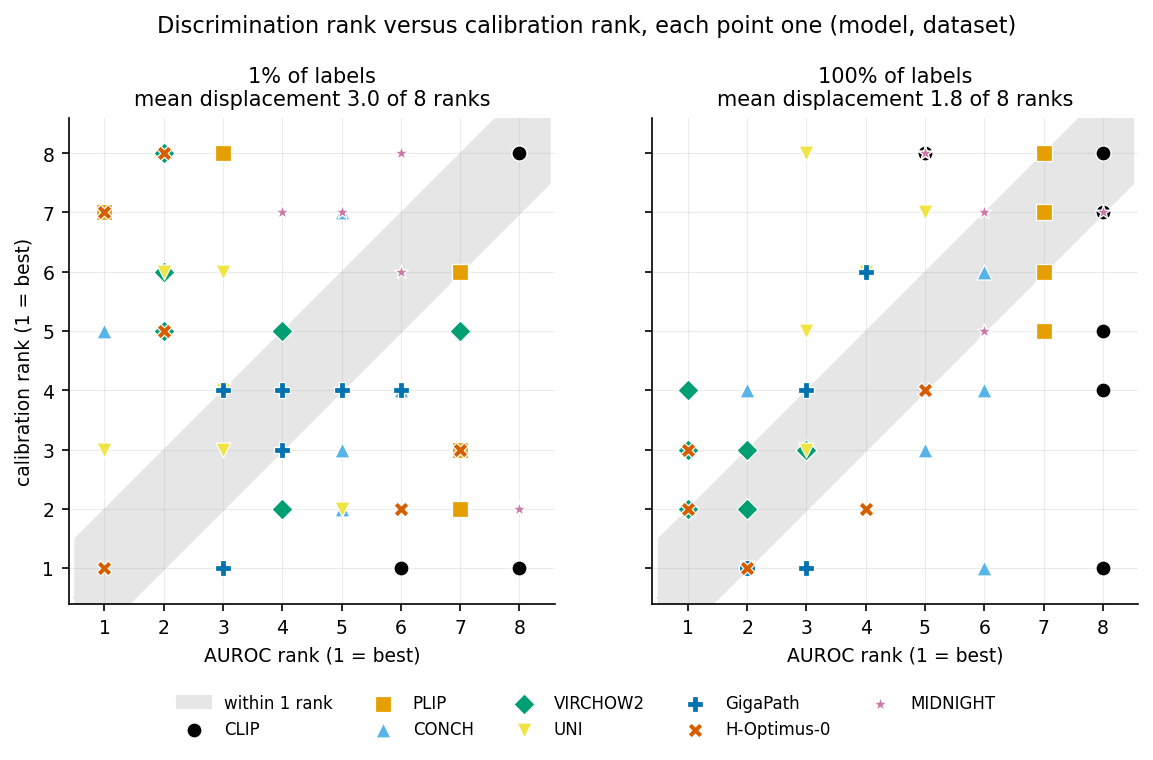

-> decoupling_scatter.pdf


In [2]:
def rank_frame(fraction, ece_col='ece_scaled_fixed'):
    rows = []
    for ds in ind['dataset'].unique():
        s = (ind[(ind.dataset == ds) & (ind.fraction == fraction)]
             .groupby('model')[['auroc', ece_col]].mean().dropna())
        if len(s) < 3:
            continue
        ra = s['auroc'].rank(ascending=False)
        rc_ = s[ece_col].rank(ascending=True)
        for m in s.index:
            rows.append(dict(dataset=ds, model=m,
                             rank_auroc=ra[m], rank_cal=rc_[m]))
    return pd.DataFrame(rows)


fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4), sharex=True, sharey=True)

for ax, frac, ttl in zip(axes, [0.01, 1.00],
                         ['1% of labels', '100% of labels']):
    d = rank_frame(frac)
    ax.plot([0.5, 8.5], [0.5, 8.5], color='0.75', lw=1, zorder=0)
    ax.fill_between([0.5, 8.5], [-0.5, 7.5], [1.5, 9.5],
                    color='0.9', zorder=0, label='within 1 rank')
    for m in MODELS:
        s = d[d.model == m]
        if s.empty:
            continue
        ax.scatter(s.rank_auroc, s.rank_cal, s=52,
                   color=COLOR[m], marker=MARKER[m],
                   edgecolor='white', linewidth=0.6, label=m, zorder=3)
    md_ = (d.rank_auroc - d.rank_cal).abs().mean()
    ax.set_title(f'{ttl}\nmean displacement {md_:.1f} of 8 ranks')
    ax.set_xlabel('AUROC rank (1 = best)')
    ax.set_xlim(0.4, 8.6); ax.set_ylim(0.4, 8.6)
    ax.set_xticks(range(1, 9)); ax.set_yticks(range(1, 9))
    ax.set_aspect('equal')
    ax.grid(alpha=0.25, lw=0.5)

axes[0].set_ylabel('calibration rank (1 = best)')
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.10))
fig.suptitle('Discrimination rank versus calibration rank, '
             'each point one (model, dataset)', y=1.02)
fig.savefig(f'{FIGDIR}/decoupling_scatter.pdf')
fig.savefig(f'{FIGDIR}/decoupling_scatter.png')
plt.show()
print('-> decoupling_scatter.pdf')

## Figure 4, all six fractions and a colourblind-safe scale

EiR7: *"fig 4 is extremely hard to read: horrible color scheme (go for
greyscale), i need datapoints between 1% and 100% to believe your claim"*.

The data for all six fractions always existed; only the two endpoints were
plotted. Here are the curves, one panel per transfer pair.

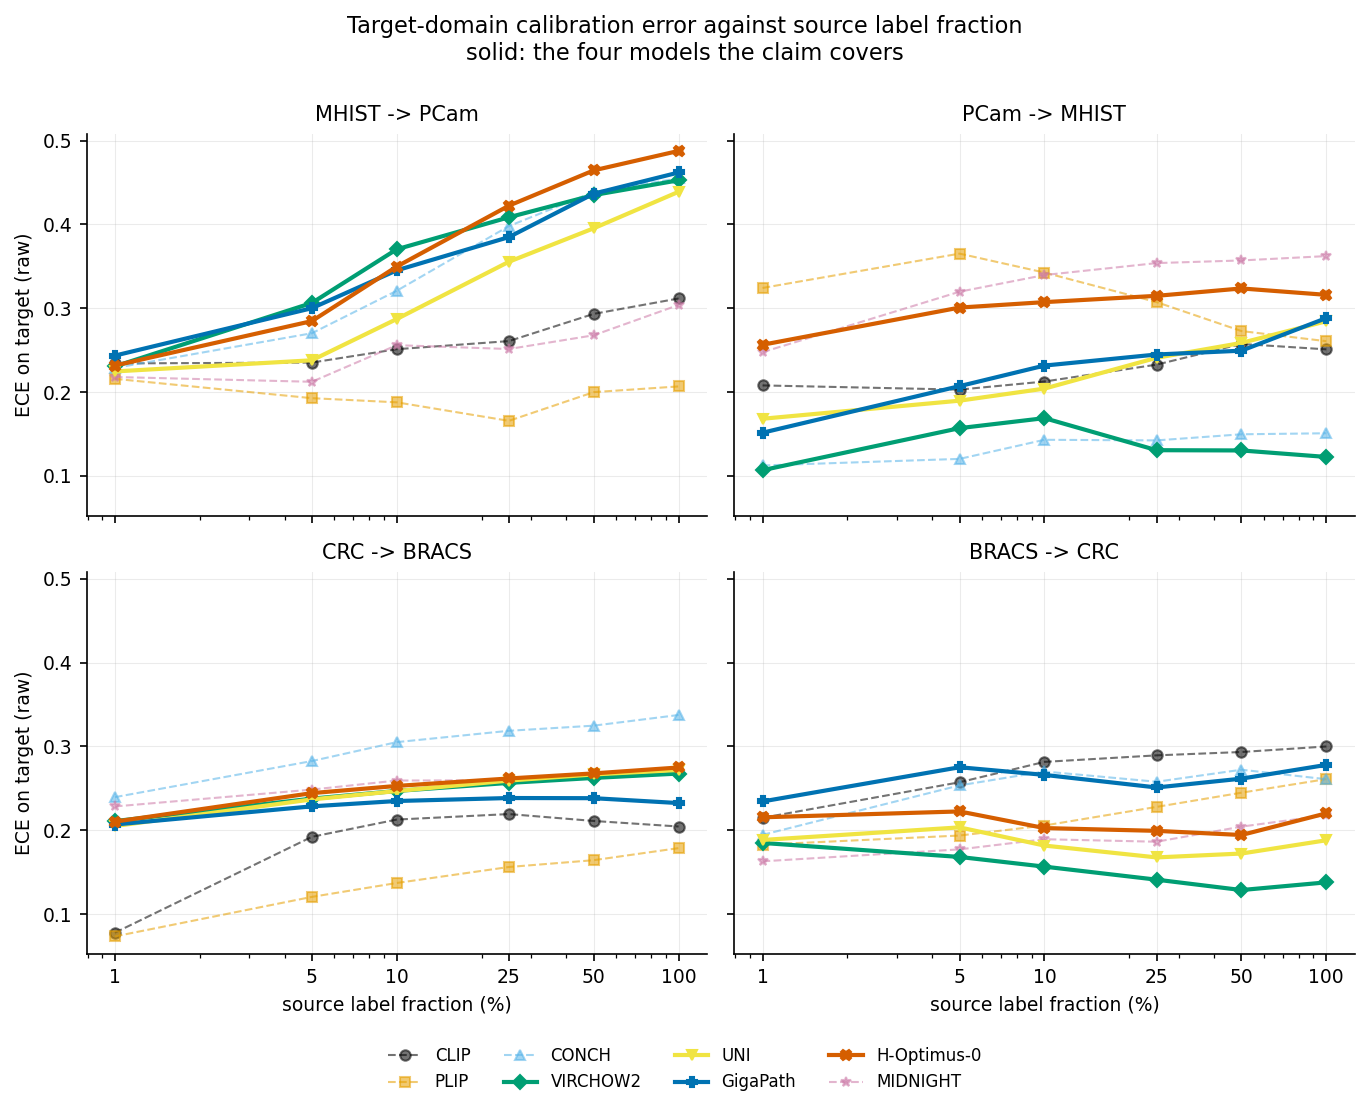

-> ood_ece_curves.pdf


In [3]:
pairs = ['MHIST->PCam', 'PCam->MHIST', 'CRC->BRACS', 'BRACS->CRC']
CLAIM = ['UNI', 'VIRCHOW2', 'GigaPath', 'H-Optimus-0']

fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.8), sharex=True, sharey=True)

for ax, pair in zip(axes.ravel(), pairs):
    sub = ood[ood.pair == pair]
    for m in MODELS:
        v = sub[sub.model == m].groupby('fraction')['ece_fixed'].mean()
        if v.empty:
            continue
        claimed = m in CLAIM
        ax.plot([f*100 for f in v.index], v.values,
                marker=MARKER[m], ms=5, color=COLOR[m],
                lw=2.0 if claimed else 1.0,
                alpha=1.0 if claimed else 0.55,
                ls='-' if claimed else '--',
                label=m, zorder=3 if claimed else 2)
    ax.set_xscale('log')
    ax.set_xticks([1, 5, 10, 25, 50, 100])
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.set_title(pair.replace('->', ' -> '))
    ax.grid(alpha=0.25, lw=0.5)

for ax in axes[1]:
    ax.set_xlabel('source label fraction (%)')
for ax in axes[:, 0]:
    ax.set_ylabel('ECE on target (raw)')

h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.07))
fig.suptitle('Target-domain calibration error against source label fraction\n'
             'solid: the four models the claim covers', y=1.00)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/ood_ece_curves.pdf')
fig.savefig(f'{FIGDIR}/ood_ece_curves.png')
plt.show()
print('-> ood_ece_curves.pdf')

## Figure 5, regenerated

The rendered title of the submitted figure still reads "Composite Reliability
Index". The metric is the Clinical Readiness Index, and OOD_Stability is now
computed as the paper defines it, the ratio of OOD to in-distribution AUROC.

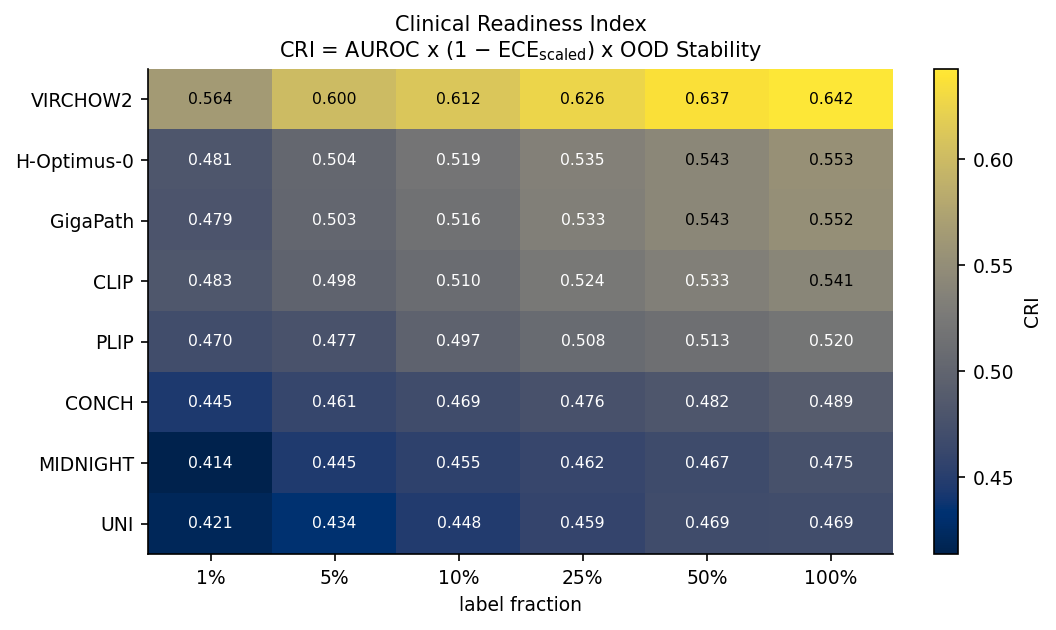

OOD_Stability, paper definition:
      VIRCHOW2: 0.7001
          CLIP: 0.6433
   H-Optimus-0: 0.6061
      GigaPath: 0.6055
          PLIP: 0.5974
      MIDNIGHT: 0.5501
         CONCH: 0.5418
           UNI: 0.5214

-> cri_heatmap.pdf


In [4]:
OOD_PAIRS = [('PCam','MHIST'), ('MHIST','PCam'),
             ('CRC','BRACS'), ('BRACS','CRC')]

id100 = ind[ind.fraction == 1.0].groupby(['model','dataset'])['auroc'].mean()

stab = {}
for m in MODELS:
    r = []
    for src, tgt in OOD_PAIRS:
        o = ood[(ood.model == m) & (ood.pair == f'{src}->{tgt}') &
                (ood.fraction == 1.0)]['auroc'].mean()
        try:
            i = id100.loc[(m, src)]
        except KeyError:
            continue
        if i and np.isfinite(o):
            r.append(min(o / i, 1.0))
    stab[m] = float(np.mean(r)) if r else np.nan

cri = np.full((len(MODELS), len(FRACTIONS)), np.nan)
for i, m in enumerate(MODELS):
    for j, f in enumerate(FRACTIONS):
        s = ind[(ind.model == m) & (ind.fraction == f)]
        if s.empty:
            continue
        a = s.groupby('dataset')['auroc'].mean().mean()
        e = float(np.clip(s.groupby('dataset')['ece_scaled_fixed']
                          .mean().mean(), 0, 1))
        cri[i, j] = a * (1 - e) * stab[m]

order = np.argsort(-np.nanmean(cri, axis=1))
cri_s = cri[order]
labels = [MODELS[i] for i in order]

fig, ax = plt.subplots(figsize=(7.0, 4.2))
im = ax.imshow(cri_s, cmap=SEQ, aspect='auto',
               vmin=np.nanmin(cri), vmax=np.nanmax(cri))
ax.set_xticks(range(len(FRACTIONS)))
ax.set_xticklabels([f'{int(f*100)}%' for f in FRACTIONS])
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('label fraction')
ax.set_title('Clinical Readiness Index\n'
             'CRI = AUROC x (1 $-$ ECE$_{\\mathrm{scaled}}$) '
             'x OOD Stability')
for i in range(cri_s.shape[0]):
    for j in range(cri_s.shape[1]):
        if np.isfinite(cri_s[i, j]):
            v = cri_s[i, j]
            rng = np.nanmax(cri) - np.nanmin(cri)
            light = (v - np.nanmin(cri)) / rng > 0.55
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=7.5, color='black' if light else 'white')
plt.colorbar(im, ax=ax, label='CRI', fraction=0.035)
fig.savefig(f'{FIGDIR}/cri_heatmap.pdf')
fig.savefig(f'{FIGDIR}/cri_heatmap.png')
plt.show()

print('OOD_Stability, paper definition:')
for m, v in sorted(stab.items(), key=lambda x: -x[1]):
    print(f'  {m:>12}: {v:.4f}')
print('\n-> cri_heatmap.pdf')

## New figure: the degeneracy audit

Reviewer tp5b hypothesised that the reported breaking points may reflect
sampling artefacts. This figure reports the measurement directly: the share of
seeds in which the probe assigns more than 99% of the test set to a single
class. It supports the reviewer's suspicion in part and refutes it in part,
which is why it belongs in the paper.

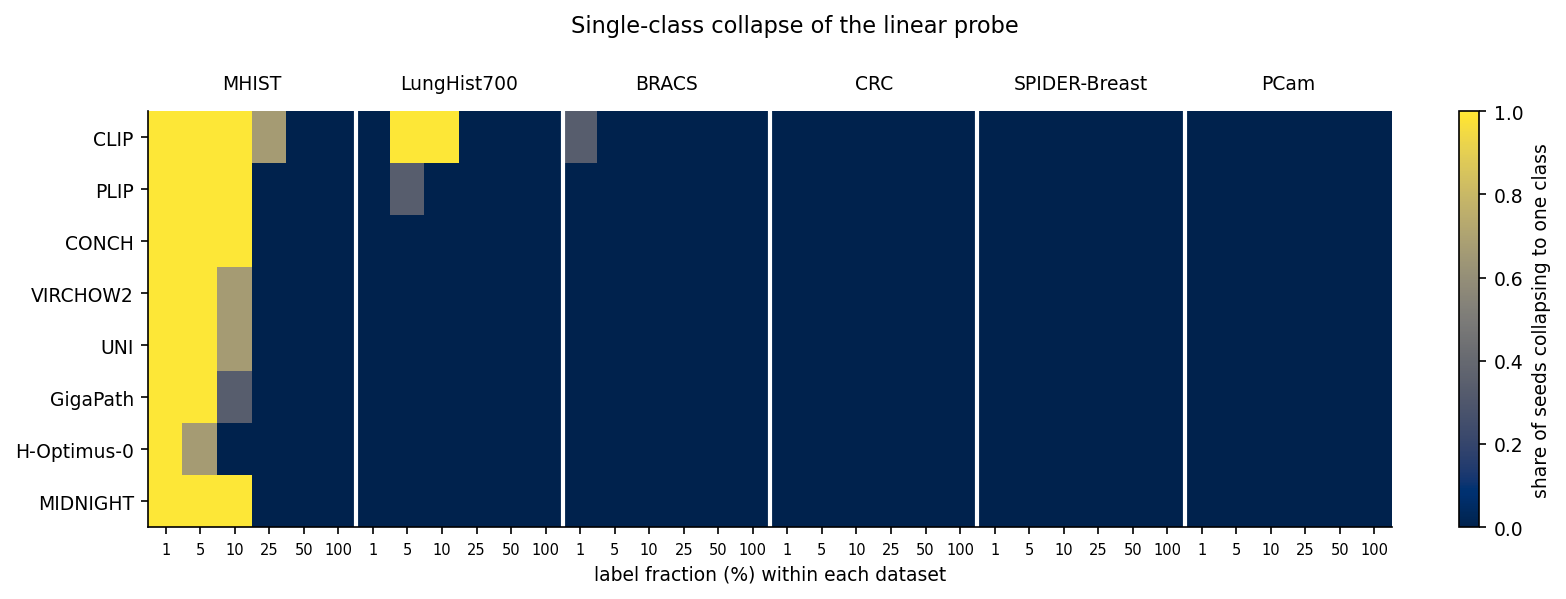

MHIST, share of seeds collapsing:
fraction     0.01  0.05  0.10  0.25  0.50  1.00
model                                          
CLIP          1.0  1.00  1.00  0.67   0.0   0.0
CONCH         1.0  1.00  1.00  0.00   0.0   0.0
GigaPath      1.0  1.00  0.33  0.00   0.0   0.0
H-Optimus-0   1.0  0.67  0.00  0.00   0.0   0.0
MIDNIGHT      1.0  1.00  1.00  0.00   0.0   0.0
PLIP          1.0  1.00  1.00  0.00   0.0   0.0
UNI           1.0  1.00  0.67  0.00   0.0   0.0
VIRCHOW2      1.0  1.00  0.67  0.00   0.0   0.0

-> degeneracy_heatmap.pdf


In [5]:
dsets = ['MHIST','LungHist700','BRACS','CRC','SPIDER-Breast','PCam']
mat = np.zeros((len(MODELS), len(dsets) * len(FRACTIONS)))

for i, m in enumerate(MODELS):
    col = 0
    for ds in dsets:
        for f in FRACTIONS:
            s = ind[(ind.model == m) & (ind.dataset == ds) &
                    (ind.fraction == f)]
            mat[i, col] = s['degenerate'].mean() if len(s) else np.nan
            col += 1

fig, ax = plt.subplots(figsize=(11.5, 3.6))
im = ax.imshow(mat, cmap=SEQ, aspect='auto', vmin=0, vmax=1)
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
ax.set_xticks(range(0, len(dsets)*len(FRACTIONS)))
ax.set_xticklabels([f'{int(f*100)}' for _ in dsets for f in FRACTIONS],
                   fontsize=7)
for k in range(1, len(dsets)):
    ax.axvline(k*len(FRACTIONS) - 0.5, color='white', lw=2)
for k, ds in enumerate(dsets):
    ax.text(k*len(FRACTIONS) + 2.5, -0.85, ds,
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('label fraction (%) within each dataset')
plt.colorbar(im, ax=ax, label='share of seeds collapsing to one class',
             fraction=0.02)
fig.suptitle('Single-class collapse of the linear probe', y=1.06)
fig.savefig(f'{FIGDIR}/degeneracy_heatmap.pdf')
fig.savefig(f'{FIGDIR}/degeneracy_heatmap.png')
plt.show()

print('MHIST, share of seeds collapsing:')
print(ind[ind.dataset == 'MHIST']
      .pivot_table(index='model', columns='fraction', values='degenerate')
      .round(2).to_string())
print('\n-> degeneracy_heatmap.pdf')

## New figure: the rank-correlation contrast

Replaces the rank-1 agreement count with the statistic that supports the
claim. Per-dataset Spearman correlations with bootstrap intervals, and the
pooled estimate across label fractions.

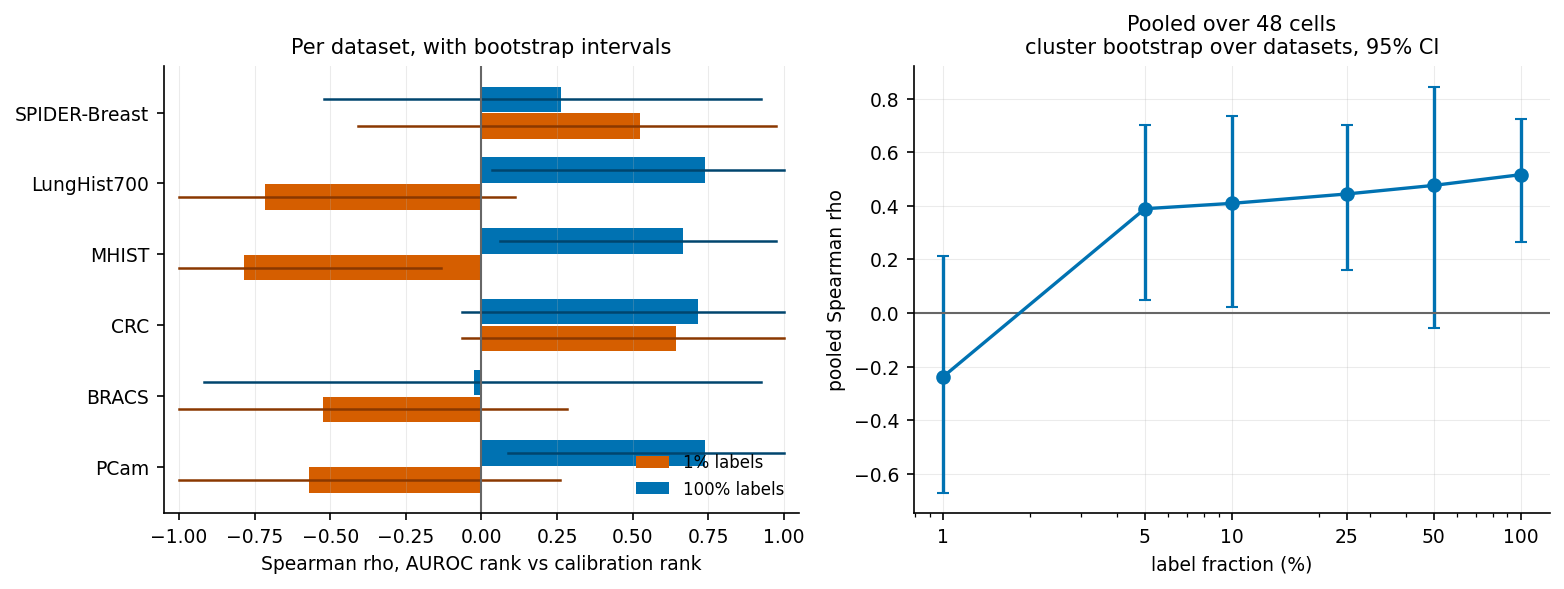

-> rank_correlation.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

# left: per dataset, 1% vs 100%
ax = axes[0]
d1 = rc[rc.fraction == 0.01].set_index('dataset')
d2 = rc[rc.fraction == 1.00].set_index('dataset')
common = [d for d in d1.index if d in d2.index]
y = np.arange(len(common))
ax.barh(y - 0.19, d1.loc[common, 'spearman'], height=0.36,
        color='#D55E00', label='1% labels')
ax.barh(y + 0.19, d2.loc[common, 'spearman'], height=0.36,
        color='#0072B2', label='100% labels')
if 'ci_lo' in d1.columns:
    for k, ds in enumerate(common):
        for off, dd, c in [(-0.19, d1, '#8a3800'), (0.19, d2, '#00456e')]:
            lo, hi, mid = dd.loc[ds,'ci_lo'], dd.loc[ds,'ci_hi'], dd.loc[ds,'spearman']
            ax.plot([lo, hi], [k+off, k+off], color=c, lw=1.2)
ax.axvline(0, color='0.4', lw=1)
ax.set_yticks(y); ax.set_yticklabels(common)
ax.set_xlabel('Spearman rho, AUROC rank vs calibration rank')
ax.set_xlim(-1.05, 1.05)
ax.legend(frameon=False, loc='lower right')
ax.set_title('Per dataset, with bootstrap intervals')
ax.grid(axis='x', alpha=0.25, lw=0.5)

# right: pooled across fractions
ax = axes[1]
pooled = {0.01: (-0.238, -0.671, 0.214), 0.05: (0.389, 0.048, 0.702),
          0.10: (0.409, 0.024, 0.734),   0.25: (0.444, 0.159, 0.702),
          0.50: (0.476, -0.056, 0.845),  1.00: (0.516, 0.266, 0.722)}
xs = [f*100 for f in pooled]
ys = [v[0] for v in pooled.values()]
lo = [v[0]-v[1] for v in pooled.values()]
hi = [v[2]-v[0] for v in pooled.values()]
ax.errorbar(xs, ys, yerr=[lo, hi], marker='o', ms=6, lw=1.6,
            color='#0072B2', capsize=3)
ax.axhline(0, color='0.4', lw=1)
ax.set_xscale('log')
ax.set_xticks([1,5,10,25,50,100])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xlabel('label fraction (%)')
ax.set_ylabel('pooled Spearman rho')
ax.set_title('Pooled over 48 cells\n'
             'cluster bootstrap over datasets, 95% CI')
ax.grid(alpha=0.25, lw=0.5)

fig.tight_layout()
fig.savefig(f'{FIGDIR}/rank_correlation.pdf')
fig.savefig(f'{FIGDIR}/rank_correlation.png')
plt.show()
print('-> rank_correlation.pdf')

## Greyscale and colourblind check

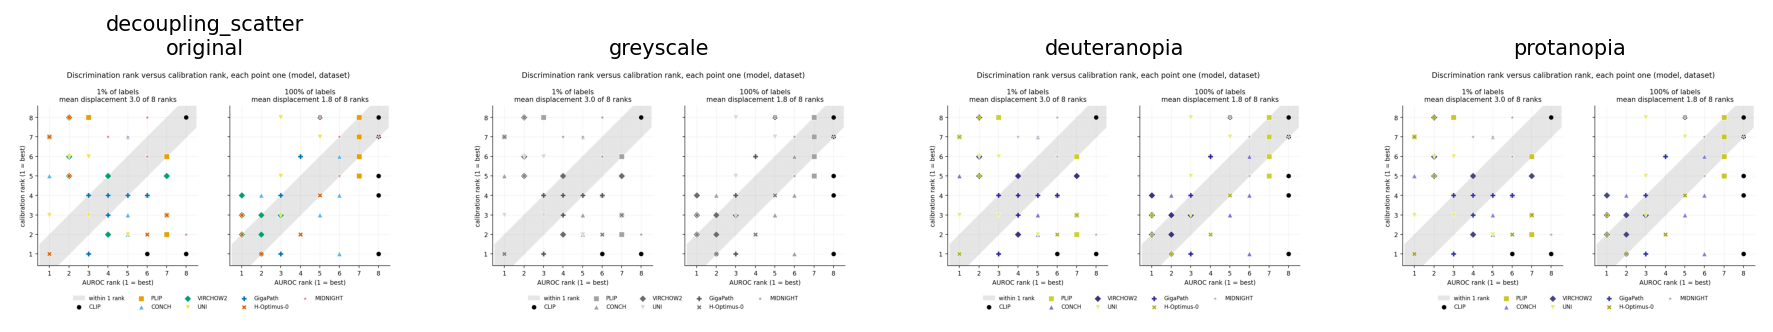

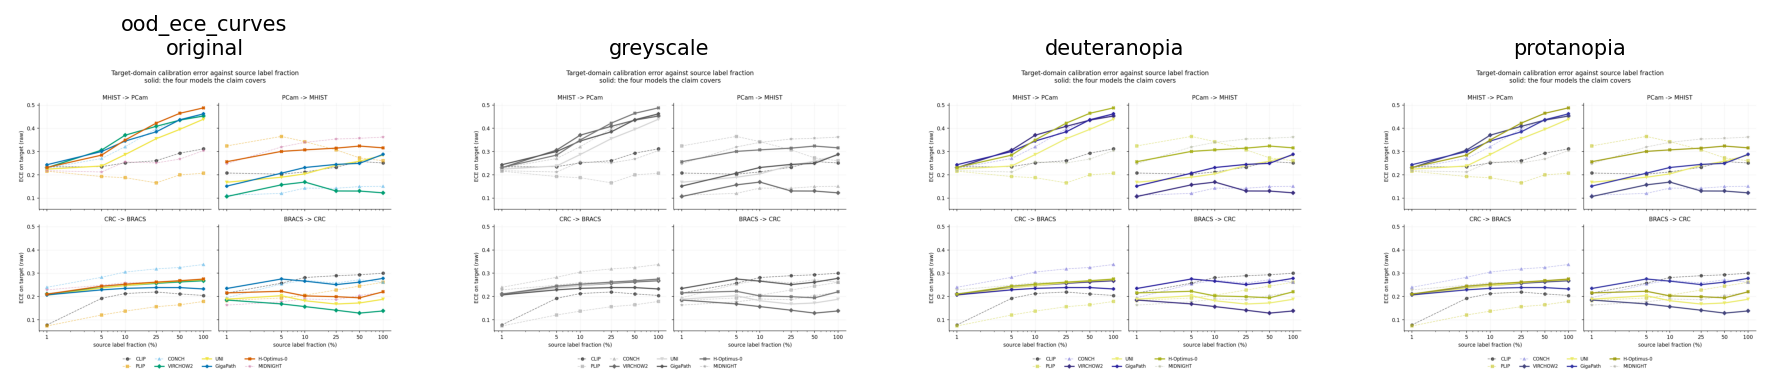

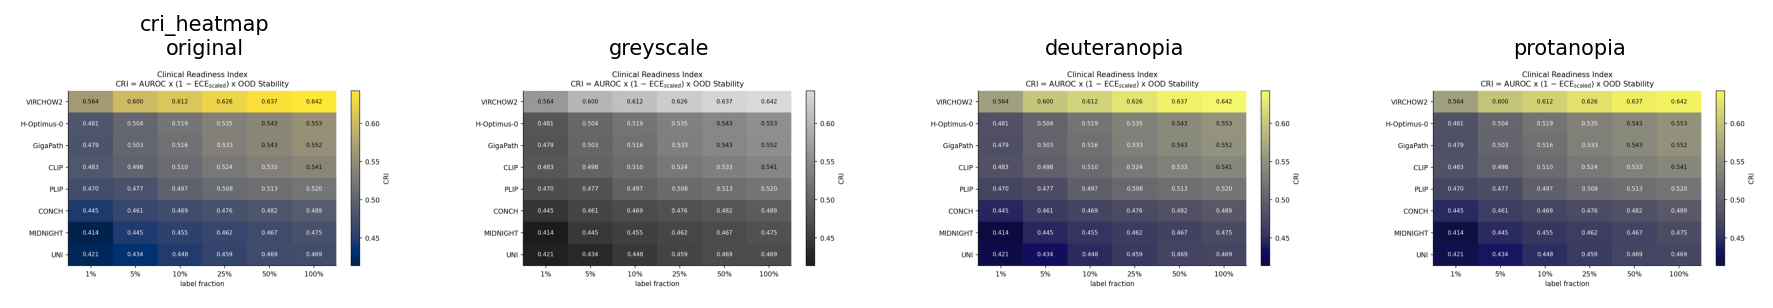

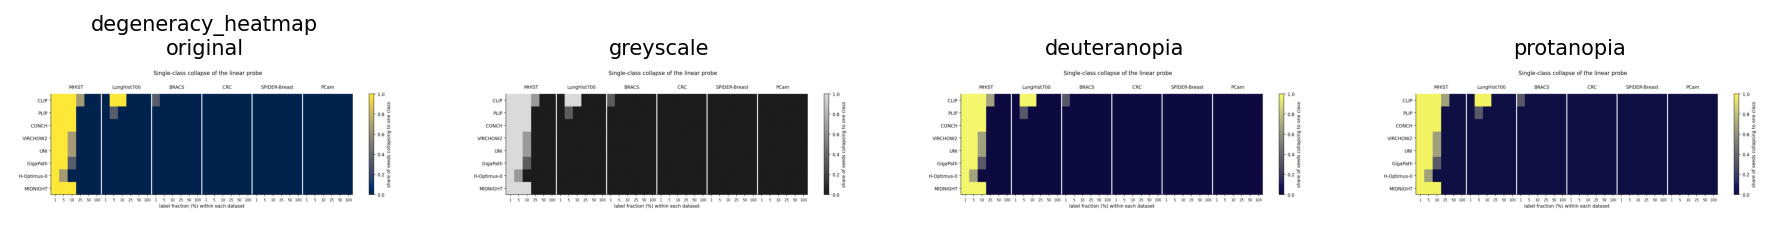

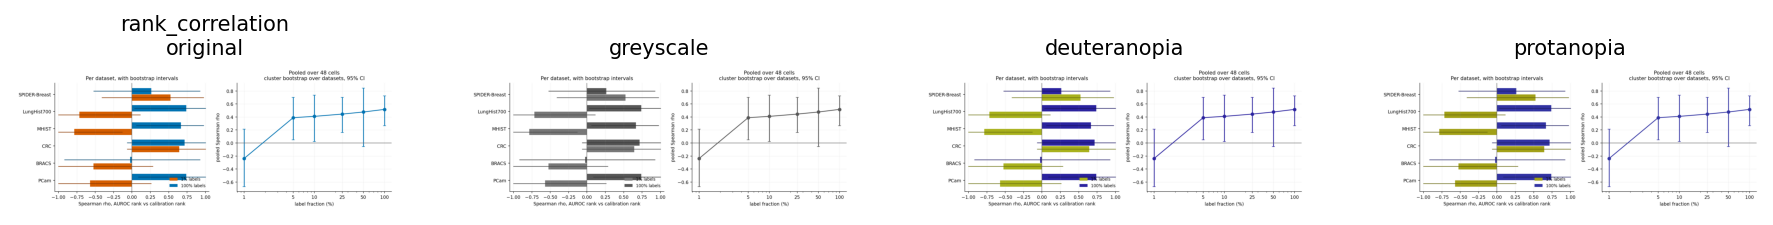


figures_v2/ contents:
  cri_heatmap.pdf                       24.1 KB
  cri_heatmap.png                       84.5 KB
  decoupling_scatter.pdf                25.0 KB
  decoupling_scatter.png                87.4 KB
  degeneracy_heatmap.pdf                22.0 KB
  degeneracy_heatmap.png                54.4 KB
  ood_ece_curves.pdf                    31.8 KB
  ood_ece_curves.png                   213.3 KB
  rank_correlation.pdf                  20.9 KB
  rank_correlation.png                  75.0 KB


In [7]:
from PIL import Image

def simulate(path):
    im = np.asarray(Image.open(path).convert('RGB'), dtype=float) / 255
    grey = im @ [0.299, 0.587, 0.114]
    # Brettel-style approximations
    M_deut = np.array([[0.625,0.375,0.0],[0.70,0.30,0.0],[0.0,0.30,0.70]])
    M_prot = np.array([[0.567,0.433,0.0],[0.558,0.442,0.0],[0.0,0.242,0.758]])
    return grey, im @ M_deut.T, im @ M_prot.T

figs = ['decoupling_scatter', 'ood_ece_curves', 'cri_heatmap',
        'degeneracy_heatmap', 'rank_correlation']

for name in figs:
    p = f'{FIGDIR}/{name}.png'
    if not os.path.exists(p):
        print('eksik:', name); continue
    g, d, pr = simulate(p)
    fig, ax = plt.subplots(1, 4, figsize=(15, 3.0))
    ax[0].imshow(Image.open(p));       ax[0].set_title(f'{name}\noriginal')
    ax[1].imshow(g, cmap='gray');      ax[1].set_title('greyscale')
    ax[2].imshow(np.clip(d, 0, 1));    ax[2].set_title('deuteranopia')
    ax[3].imshow(np.clip(pr, 0, 1));   ax[3].set_title('protanopia')
    for a in ax:
        a.axis('off')
    plt.show()

print('\nfigures_v2/ contents:')
for f in sorted(os.listdir(FIGDIR)):
    print(f'  {f:<34} {os.path.getsize(f"{FIGDIR}/{f}")/1024:>7.1f} KB')

## Next

Upload the PDFs into the Overleaf project's `figures/` directory and update
the `\includegraphics` paths:

| new file | replaces |
|---|---|
| `decoupling_scatter.pdf` | `decoupling_heatmap.pdf` (Figure 2) |
| `ood_ece_curves.pdf` | `ood_ece_heatmap.pdf` (Figure 4) |
| `cri_heatmap.pdf` | the old `cri_heatmap.pdf` (Figure 5) |
| `degeneracy_heatmap.pdf` | new, add to the appendix |
| `rank_correlation.pdf` | new, add to the appendix |

Captions need rewriting to match. Figure 2's caption currently cites the
rank-1 agreement count, which is no longer the statistic being shown.